In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/alitaqishah/iran-war-oil-shock-2026-brent-and-gas-tracker/iran_war_oil_prices_daily_2026.csv
/kaggle/input/datasets/alitaqishah/iran-war-oil-shock-2026-brent-and-gas-tracker/iran_war_gas_prices_by_state.csv
/kaggle/input/datasets/alitaqishah/iran-war-oil-shock-2026-brent-and-gas-tracker/iran_war_key_events_timeline.csv


# Problem Statement

The global oil market is highly volatile, and predicting Brent crude prices accurately is essential for:

* Energy planning and procurement
* Trading and risk management strategies
* Economic and policy decision-making

Traditional forecasting methods often fail to capture the complex, non-linear relationships between oil prices and influencing factors. By leveraging AI and machine learning, we can model these relationships, incorporating:

* Historical price trends and lag effects
* Shipping traffic through key chokepoints like the Strait of Hormuz
* Short-term and long-term market dynamics

**Objectives of This Notebook**
* **Analyze Oil Market Dynamics** – Understand how historical patterns and shocks impact Brent crude prices.
* **Feature Engineering** – Create meaningful predictors such as lagged prices, rolling averages, and shipping data.
Model Development – Build and compare multiple machine learning models (Linear Regression, Random Forest, Gradient Boosting, XGBoost).
* **Model Evaluation** – Assess performance using MAE, RMSE, R², and MAPE, including baseline (naive) comparisons.
* **Forecasting** – Generate short-term predictions with confidence intervals for decision support.
* **Insights & Actionable Analysis** – Identify key drivers, assess crisis impact, and provide guidance for traders, policymakers, and researchers.

In [2]:


import warnings
warnings.filterwarnings('ignore')


import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)


import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import matplotlib.dates as mdates
import pandas as pd


import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb
from scipy.stats import norm

In [3]:
plt.rcParams['figure.figsize'] = (20, 12)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_style("whitegrid")
sns.set_palette("husl")

# Load datasets

In [4]:

oil_prices_daily = pd.read_csv('/kaggle/input/datasets/alitaqishah/iran-war-oil-shock-2026-brent-and-gas-tracker/iran_war_oil_prices_daily_2026.csv')
gas_prices = pd.read_csv('/kaggle/input/datasets/alitaqishah/iran-war-oil-shock-2026-brent-and-gas-tracker/iran_war_gas_prices_by_state.csv')
key_events = pd.read_csv('/kaggle/input/datasets/alitaqishah/iran-war-oil-shock-2026-brent-and-gas-tracker/iran_war_key_events_timeline.csv')



In [5]:

# Convert dates
oil_prices_daily['date'] = pd.to_datetime(oil_prices_daily['date'])
key_events['date'] = pd.to_datetime(key_events['date'])

# Create derived features
oil_prices_daily['brent_daily_return'] = oil_prices_daily['brent_usd_barrel'].pct_change() * 100
oil_prices_daily['brent_volatility'] = oil_prices_daily['brent_daily_return'].rolling(window=3).std()
oil_prices_daily['price_spread'] = oil_prices_daily['brent_usd_barrel'] - oil_prices_daily['wti_usd_barrel']
oil_prices_daily['shipping_collapse_rate'] = (1 - oil_prices_daily['strait_hormuz_daily_ships'] / 138) * 100

# Add event markers
oil_prices_daily['has_event'] = oil_prices_daily['date'].isin(key_events['date'])


#  EDA

In [6]:


# Helper function to safely get peak date
def get_peak_date(df, column):
    peak_value = df[column].max()
    peak_date = df.loc[df[column] == peak_value, 'date'].iloc[0]
    return pd.to_datetime(peak_date)   # ensures Timestamp

metrics_summary = pd.DataFrame({
    'Metric': ['Brent Crude', 'WTI Crude', 'Dubai Crude', 'US Gas', 'US Diesel', 'Hormuz Ships'],
    'Pre-War (Feb 27)': [
        oil_prices_daily[oil_prices_daily['date'] == '2026-02-27']['brent_usd_barrel'].values[0],
        oil_prices_daily[oil_prices_daily['date'] == '2026-02-27']['wti_usd_barrel'].values[0],
        oil_prices_daily[oil_prices_daily['date'] == '2026-02-27']['dubai_usd_barrel'].values[0],
        oil_prices_daily[oil_prices_daily['date'] == '2026-02-27']['us_gas_avg_gallon'].values[0],
        oil_prices_daily[oil_prices_daily['date'] == '2026-02-27']['us_diesel_avg_gallon'].values[0],
        oil_prices_daily[oil_prices_daily['date'] == '2026-02-27']['strait_hormuz_daily_ships'].values[0]
    ],
    'Peak Value': [
        oil_prices_daily['brent_usd_barrel'].max(),
        oil_prices_daily['wti_usd_barrel'].max(),
        oil_prices_daily['dubai_usd_barrel'].max(),
        oil_prices_daily['us_gas_avg_gallon'].max(),
        oil_prices_daily['us_diesel_avg_gallon'].max(),
        oil_prices_daily['strait_hormuz_daily_ships'].max()
    ],
    'Peak Date': [
        get_peak_date(oil_prices_daily, 'brent_usd_barrel').strftime('%b %d'),
        get_peak_date(oil_prices_daily, 'wti_usd_barrel').strftime('%b %d'),
        get_peak_date(oil_prices_daily, 'dubai_usd_barrel').strftime('%b %d'),
        get_peak_date(oil_prices_daily, 'us_gas_avg_gallon').strftime('%b %d'),
        get_peak_date(oil_prices_daily, 'us_diesel_avg_gallon').strftime('%b %d'),
        get_peak_date(oil_prices_daily, 'strait_hormuz_daily_ships').strftime('%b %d')
    ],
    'Total Change': [
        oil_prices_daily['brent_usd_barrel'].max() - oil_prices_daily[oil_prices_daily['date'] == '2026-02-27']['brent_usd_barrel'].values[0],
        oil_prices_daily['wti_usd_barrel'].max() - oil_prices_daily[oil_prices_daily['date'] == '2026-02-27']['wti_usd_barrel'].values[0],
        oil_prices_daily['dubai_usd_barrel'].max() - oil_prices_daily[oil_prices_daily['date'] == '2026-02-27']['dubai_usd_barrel'].values[0],
        oil_prices_daily['us_gas_avg_gallon'].max() - oil_prices_daily[oil_prices_daily['date'] == '2026-02-27']['us_gas_avg_gallon'].values[0],
        oil_prices_daily['us_diesel_avg_gallon'].max() - oil_prices_daily[oil_prices_daily['date'] == '2026-02-27']['us_diesel_avg_gallon'].values[0],
        oil_prices_daily['strait_hormuz_daily_ships'].max() - oil_prices_daily[oil_prices_daily['date'] == '2026-02-27']['strait_hormuz_daily_ships'].values[0]
    ],
    '% Change': [
        ((oil_prices_daily['brent_usd_barrel'].max() - oil_prices_daily[oil_prices_daily['date'] == '2026-02-27']['brent_usd_barrel'].values[0]) / 
         oil_prices_daily[oil_prices_daily['date'] == '2026-02-27']['brent_usd_barrel'].values[0]) * 100,
        ((oil_prices_daily['wti_usd_barrel'].max() - oil_prices_daily[oil_prices_daily['date'] == '2026-02-27']['wti_usd_barrel'].values[0]) / 
         oil_prices_daily[oil_prices_daily['date'] == '2026-02-27']['wti_usd_barrel'].values[0]) * 100,
        ((oil_prices_daily['dubai_usd_barrel'].max() - oil_prices_daily[oil_prices_daily['date'] == '2026-02-27']['dubai_usd_barrel'].values[0]) / 
         oil_prices_daily[oil_prices_daily['date'] == '2026-02-27']['dubai_usd_barrel'].values[0]) * 100,
        ((oil_prices_daily['us_gas_avg_gallon'].max() - oil_prices_daily[oil_prices_daily['date'] == '2026-02-27']['us_gas_avg_gallon'].values[0]) / 
         oil_prices_daily[oil_prices_daily['date'] == '2026-02-27']['us_gas_avg_gallon'].values[0]) * 100,
        ((oil_prices_daily['us_diesel_avg_gallon'].max() - oil_prices_daily[oil_prices_daily['date'] == '2026-02-27']['us_diesel_avg_gallon'].values[0]) / 
         oil_prices_daily[oil_prices_daily['date'] == '2026-02-27']['us_diesel_avg_gallon'].values[0]) * 100,
        ((oil_prices_daily['strait_hormuz_daily_ships'].max() - oil_prices_daily[oil_prices_daily['date'] == '2026-02-27']['strait_hormuz_daily_ships'].values[0]) / 
         oil_prices_daily[oil_prices_daily['date'] == '2026-02-27']['strait_hormuz_daily_ships'].values[0]) * 100
    ]
})

print(metrics_summary.to_string(index=False))



      Metric  Pre-War (Feb 27)  Peak Value Peak Date  Total Change  % Change
 Brent Crude             73.10      110.30    Mar 20         37.20     50.89
   WTI Crude             67.80       96.20    Mar 20         28.40     41.89
 Dubai Crude             72.20      112.10    Mar 20         39.90     55.26
      US Gas              2.92        3.92    Mar 20          1.00     34.25
   US Diesel              3.75        5.10    Mar 20          1.35     36.00
Hormuz Ships            138.00      138.00    Feb 09          0.00      0.00


## correlation Analysis

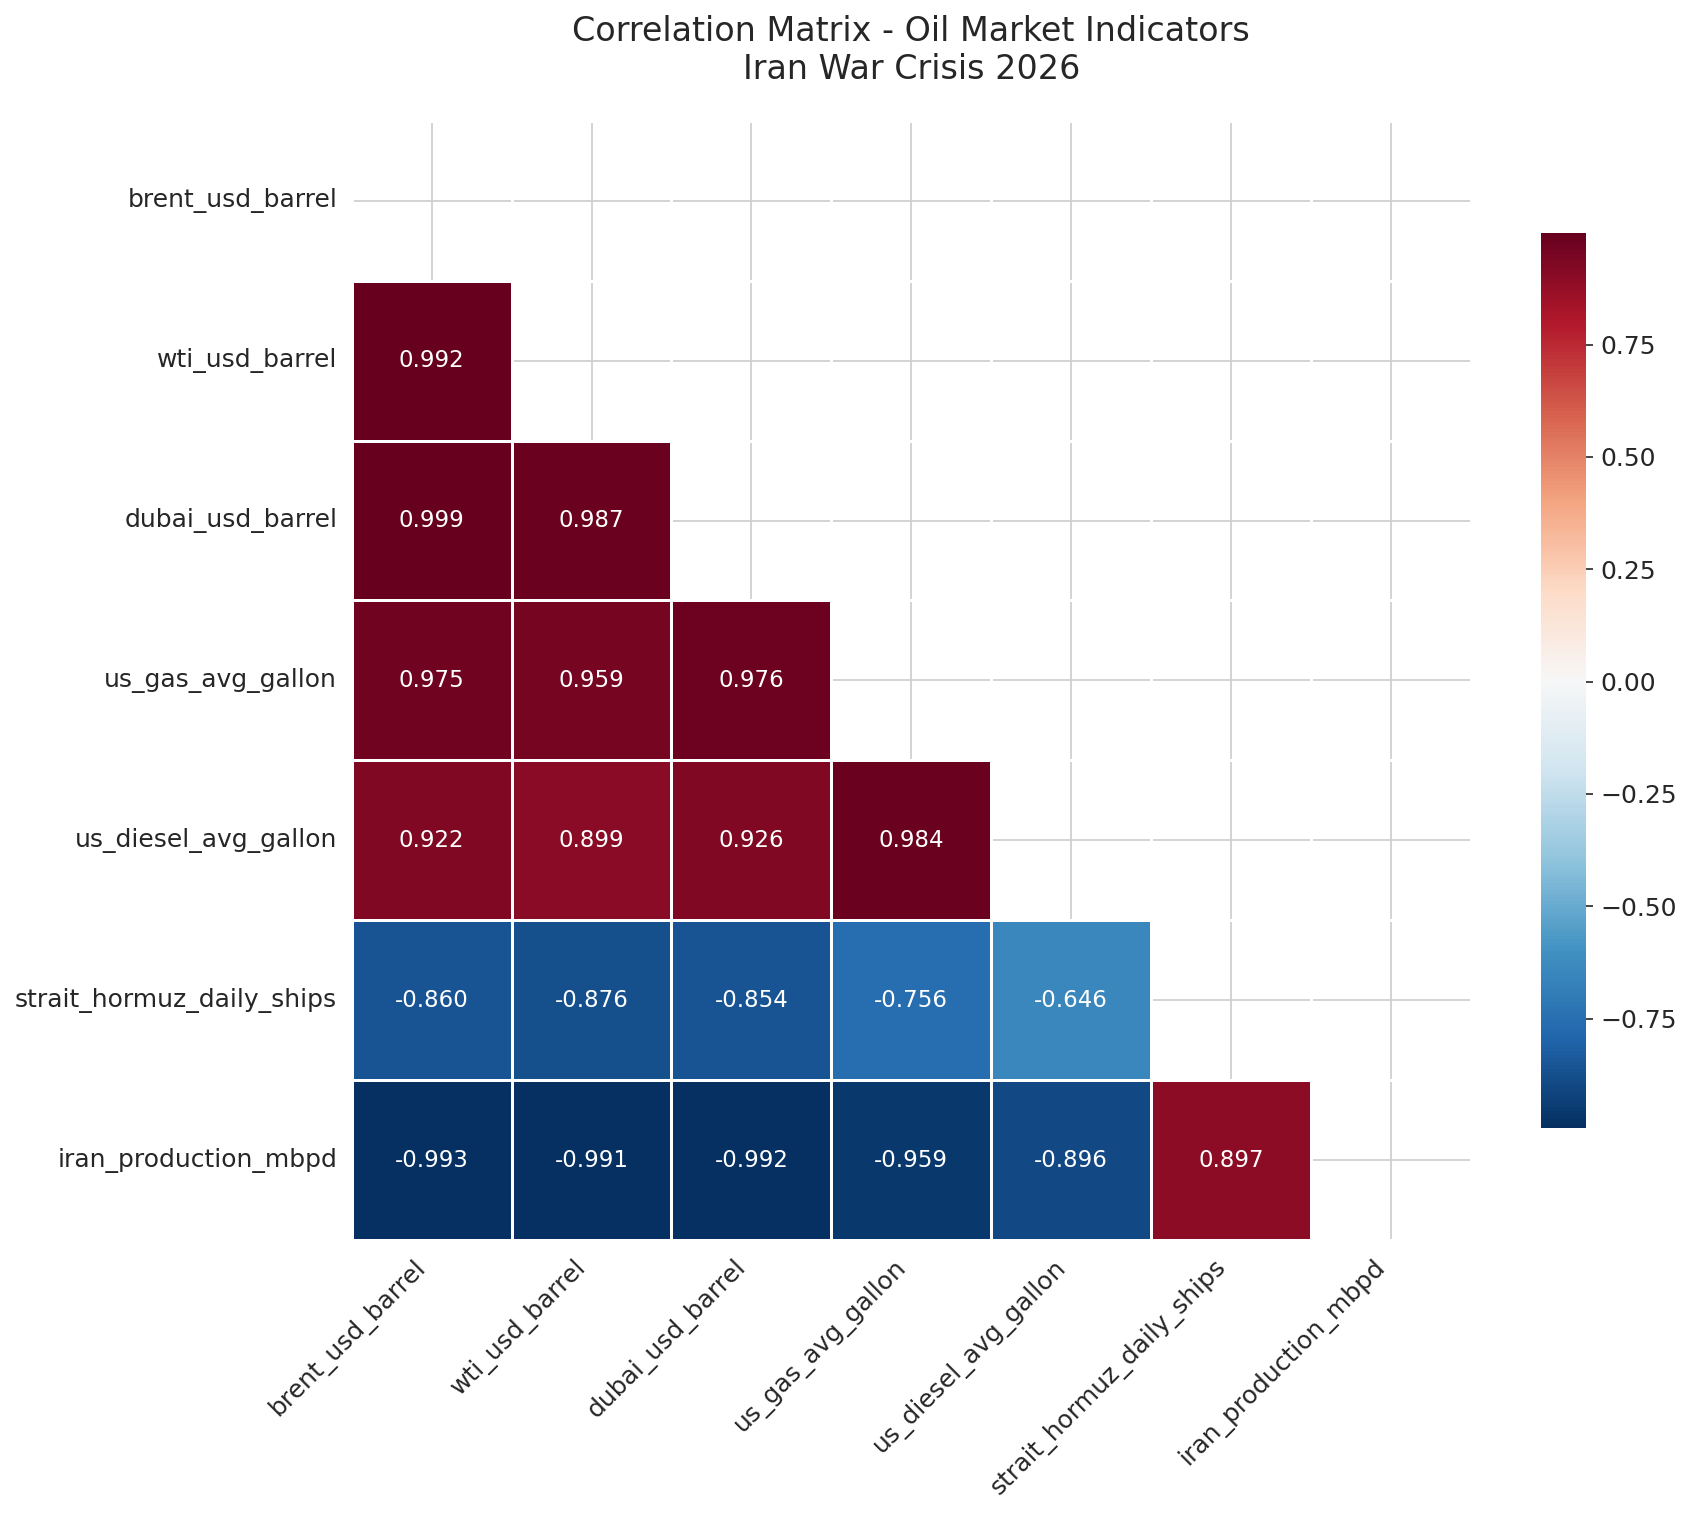

In [7]:


correlation_vars = ['brent_usd_barrel', 'wti_usd_barrel', 'dubai_usd_barrel', 
                    'us_gas_avg_gallon', 'us_diesel_avg_gallon', 'strait_hormuz_daily_ships',
                    'iran_production_mbpd']
corr_matrix = oil_prices_daily[correlation_vars].corr()

# Create enhanced correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={'size': 11})
plt.title('Correlation Matrix - Oil Market Indicators\nIran War Crisis 2026', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [8]:


import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create subplot layout
fig = make_subplots(
    rows=4, cols=2,
    subplot_titles=(
        "Brent vs WTI vs Dubai (Oil Shock)",
        "Fuel Prices (Gasoline vs Diesel)",
        "Shipping Collapse Impact",
        "Volatility Regime Shift",
        "Price vs Shipping Relationship",
        "Return Distribution (Pre vs Post War)",
        "Rolling Trend (Brent)",
        "Cumulative Returns"
    )
)


#  Oil Prices

fig.add_trace(go.Scatter(x=oil_prices_daily['date'], y=oil_prices_daily['brent_usd_barrel'],
                         name='Brent', line=dict(width=3)), row=1, col=1)

fig.add_trace(go.Scatter(x=oil_prices_daily['date'], y=oil_prices_daily['wti_usd_barrel'],
                         name='WTI'), row=1, col=1)

fig.add_trace(go.Scatter(x=oil_prices_daily['date'], y=oil_prices_daily['dubai_usd_barrel'],
                         name='Dubai'), row=1, col=1)


# Fuel Prices

fig.add_trace(go.Scatter(x=oil_prices_daily['date'], y=oil_prices_daily['us_gas_avg_gallon'],
                         name='Gasoline'), row=1, col=2)

fig.add_trace(go.Scatter(x=oil_prices_daily['date'], y=oil_prices_daily['us_diesel_avg_gallon'],
                         name='Diesel'), row=1, col=2)


#  Shipping Collapse

fig.add_trace(go.Scatter(x=oil_prices_daily['date'],
                         y=oil_prices_daily['strait_hormuz_daily_ships'],
                         name='Ships', fill='tozeroy'), row=2, col=1)


# Volatility

fig.add_trace(go.Bar(x=oil_prices_daily['date'],
                     y=oil_prices_daily['brent_volatility'],
                     name='Volatility'), row=2, col=2)


#  Scatter (Shipping vs Price)

fig.add_trace(go.Scatter(
    x=oil_prices_daily['strait_hormuz_daily_ships'],
    y=oil_prices_daily['brent_usd_barrel'],
    mode='markers',
    name='Price vs Ships'
), row=3, col=1)


#  Distribution (Pre vs Post)

pre = oil_prices_daily[oil_prices_daily['date'] < '2026-02-28']['brent_daily_return']
post = oil_prices_daily[oil_prices_daily['date'] >= '2026-02-28']['brent_daily_return']

fig.add_trace(go.Histogram(x=pre, name='Pre-War', opacity=0.6), row=3, col=2)
fig.add_trace(go.Histogram(x=post, name='Post-War', opacity=0.6), row=3, col=2)


#  Rolling Mean Trend

rolling = oil_prices_daily['brent_usd_barrel'].rolling(5).mean()

fig.add_trace(go.Scatter(x=oil_prices_daily['date'], y=rolling,
                         name='Rolling Mean (5D)', line=dict(dash='dash')), row=4, col=1)


#  Cumulative Returns

cum_return = (1 + oil_prices_daily['brent_daily_return']/100).cumprod()

fig.add_trace(go.Scatter(x=oil_prices_daily['date'], y=cum_return,
                         name='Cumulative Return'), row=4, col=2)



fig.update_layout(
    height=1200,
    width=1200,
    title=" Grandmaster Oil Market Dashboard (Advanced Insights)",
    showlegend=True
)

fig.show()

#  VISUALIZATIONS
##  Multi-Panel
 * Crude Oil Prices (Brent, WTI, Dubai)
  * US Gas and Diesel Prices
  * Strait of Hormuz Shipping Traffic
 *  Percentage Change Comparison
  * Market Volatility (3-day rolling)
##  Geographic Analysis - State Gas Prices
## Regional Analysis Visualization
* Regional prices bar chart
 * Regional percentage increase


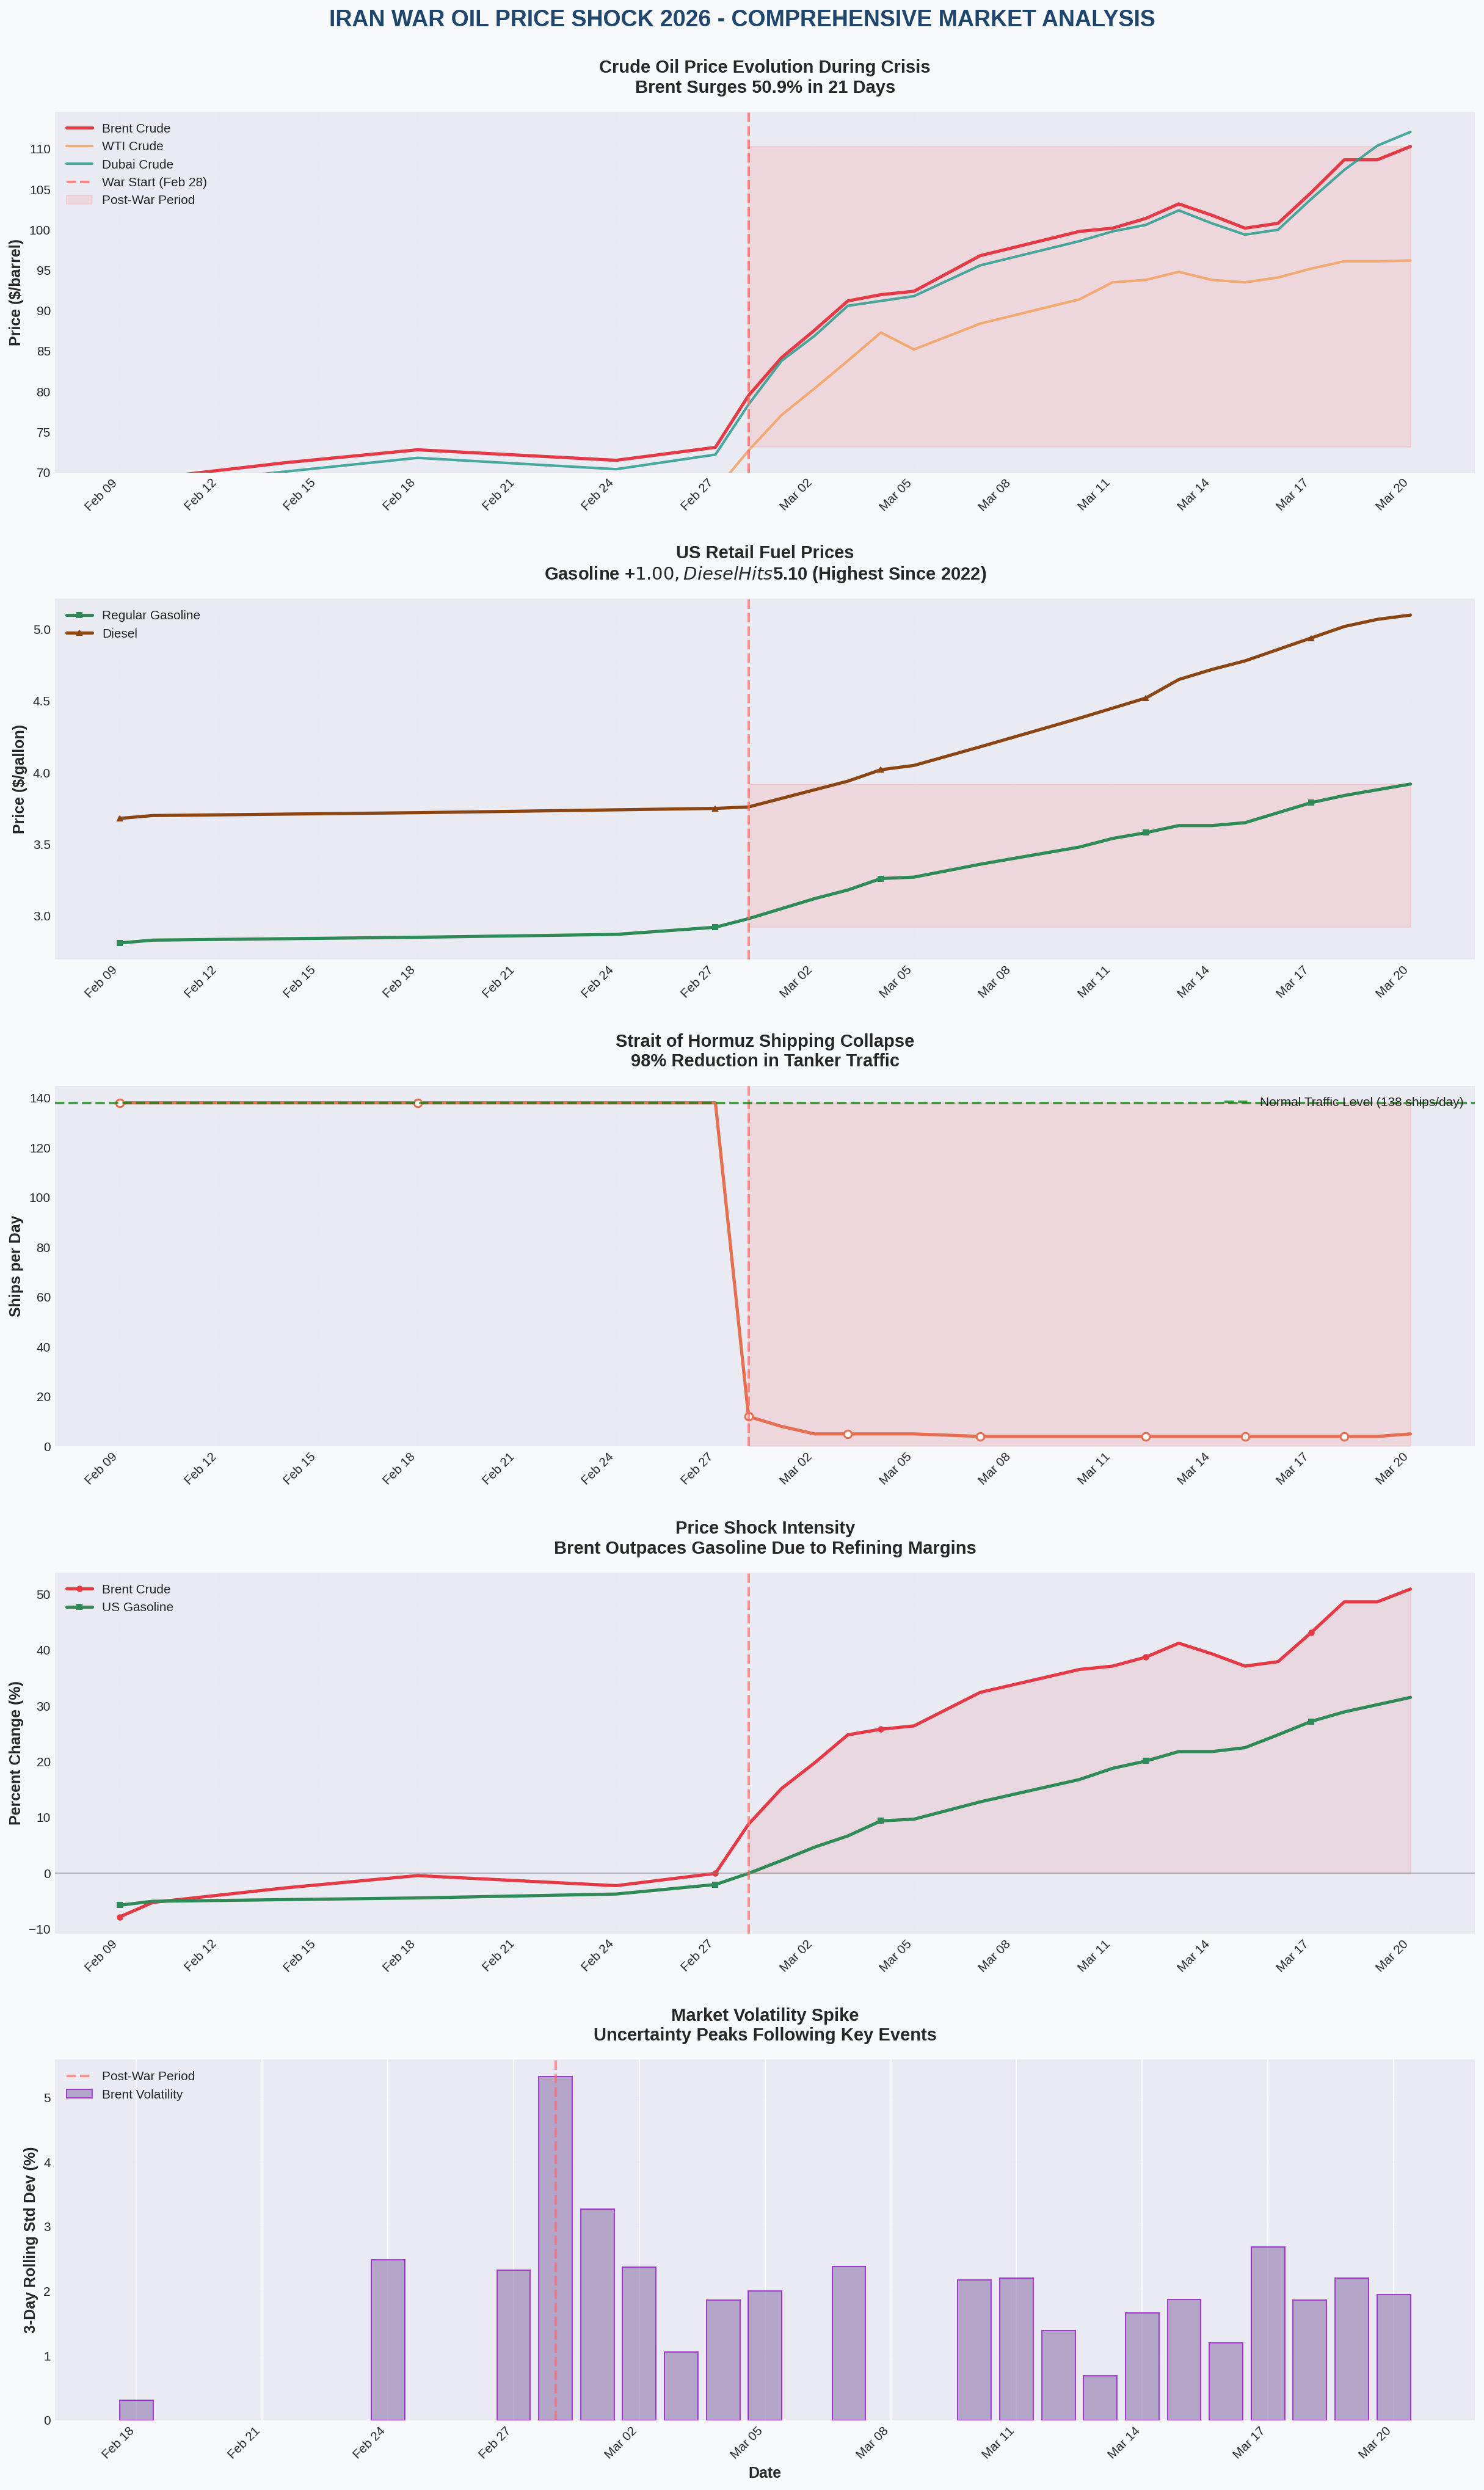

                     GEOGRAPHIC ANALYSIS - STATE GAS PRICES                     


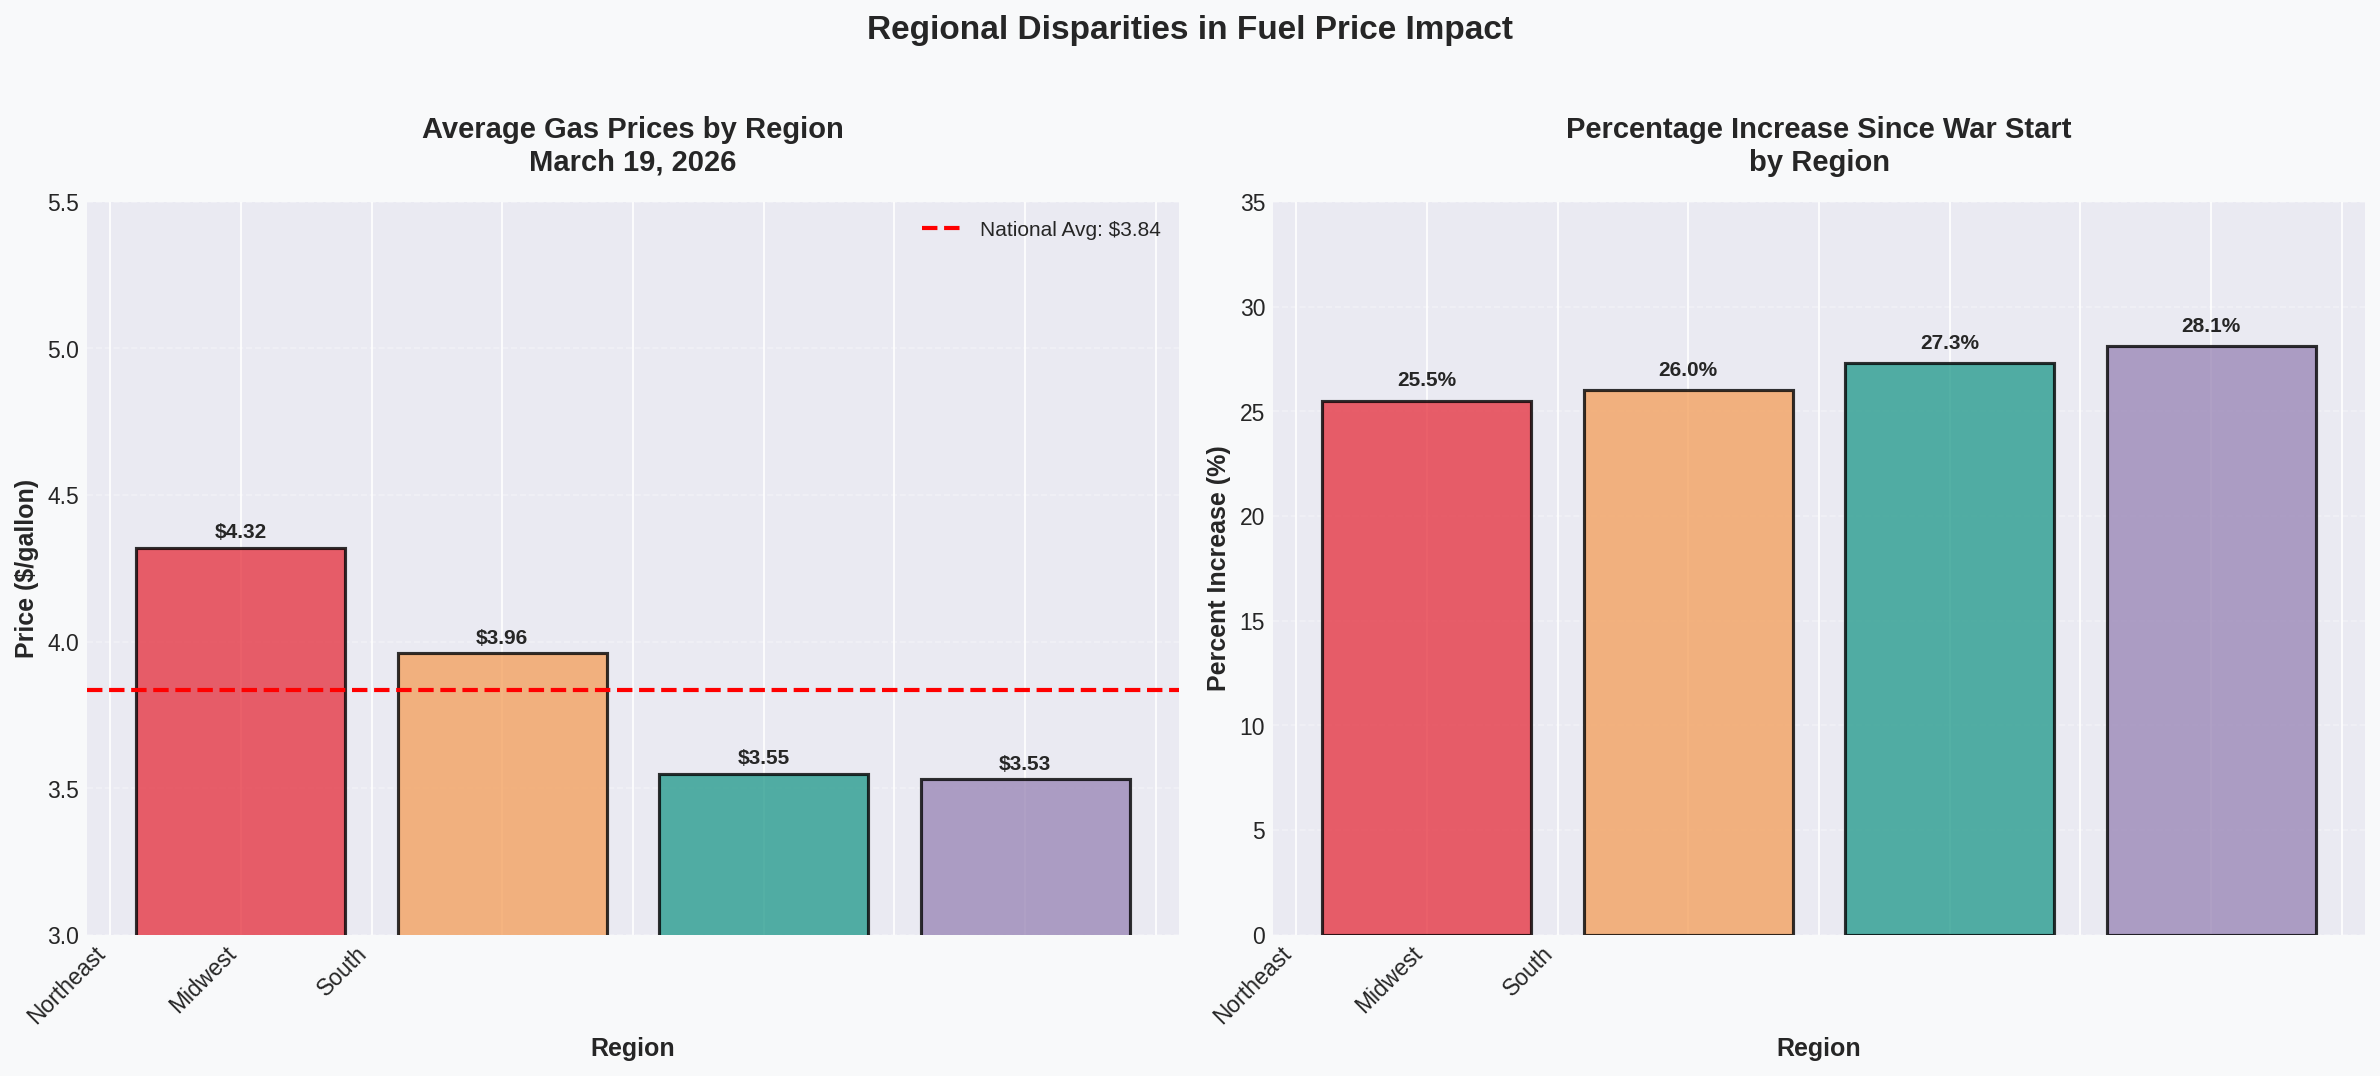

                              REGIONAL STATISTICS                               
           Mean Price  Std Dev  Min Price  Max Price  Avg % Increase  Avg $ Increase
region                                                                              
West             4.32     0.65       3.58       5.53           25.51            0.87
Northeast        3.96     0.14       3.74       4.22           26.03            0.82
Midwest          3.55     0.18       3.25       3.92           27.32            0.76
South            3.53     0.14       3.24       3.72           28.11            0.77
• National Average Gas Price: $3.84/gallon
• Highest Regional Average: West ($4.32)
• Lowest Regional Average: South ($3.53)
• Regional Price Spread: $0.79
• National Average Increase: $0.81 (26.8%)


In [9]:



plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 10


fig = plt.figure(figsize=(20, 28))
gs = fig.add_gridspec(5, 2, hspace=0.35, wspace=0.25, top=0.95, bottom=0.05)


COLORS = {
    'brent': '#E63946',      # Vibrant red
    'wti': '#F4A261',        # Warm orange  
    'dubai': '#2A9D8F',      # Teal
    'gasoline': '#2E8B57',   # Forest green
    'diesel': '#8B4513',     # Saddle brown
    'shipping': '#E76F51',   # Terracotta
    'volatility': '#9C89B8', # Lavender
    'highlight': '#FF6B6B',  # Light red
    'grid': '#E9ECEF'        # Light gray
}

#  Crude Oil Prices (Brent, WTI, Dubai)
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(oil_prices_daily['date'], oil_prices_daily['brent_usd_barrel'], 
         linewidth=2.5, label='Brent Crude', color=COLORS['brent'])
ax1.plot(oil_prices_daily['date'], oil_prices_daily['wti_usd_barrel'], 
         linewidth=2, label='WTI Crude', color=COLORS['wti'], alpha=0.85)
ax1.plot(oil_prices_daily['date'], oil_prices_daily['dubai_usd_barrel'], 
         linewidth=2, label='Dubai Crude', color=COLORS['dubai'], alpha=0.85)
ax1.axvline(pd.Timestamp('2026-02-28'), color=COLORS['highlight'], linestyle='--', 
            linewidth=2, alpha=0.8, label='War Start (Feb 28)', zorder=5)
ax1.fill_between(oil_prices_daily['date'], 73.10, oil_prices_daily['brent_usd_barrel'].max(),
                  where=(oil_prices_daily['date'] >= '2026-02-28'), 
                  alpha=0.15, color=COLORS['highlight'], label='Post-War Period')
ax1.set_ylabel('Price ($/barrel)', fontsize=12, fontweight='semibold')
ax1.set_title('Crude Oil Price Evolution During Crisis\nBrent Surges 50.9% in 21 Days', 
              fontsize=14, fontweight='bold', pad=15)
ax1.legend(loc='upper left', fontsize=10, framealpha=0.9, fancybox=True)
ax1.grid(True, alpha=0.3, linestyle='--', color=COLORS['grid'])
ax1.set_ylim(bottom=70)

#  US Gas and Diesel Prices
ax2 = fig.add_subplot(gs[1, :])
ax2.plot(oil_prices_daily['date'], oil_prices_daily['us_gas_avg_gallon'], 
         linewidth=2.5, label='Regular Gasoline', color=COLORS['gasoline'], marker='s', markersize=4, markevery=5)
ax2.plot(oil_prices_daily['date'], oil_prices_daily['us_diesel_avg_gallon'], 
         linewidth=2.5, label='Diesel', color=COLORS['diesel'], marker='^', markersize=4, markevery=5)
ax2.axvline(pd.Timestamp('2026-02-28'), color=COLORS['highlight'], linestyle='--', linewidth=2, alpha=0.7)
ax2.fill_between(oil_prices_daily['date'], 2.92, oil_prices_daily['us_gas_avg_gallon'].max(),
                  where=(oil_prices_daily['date'] >= '2026-02-28'), alpha=0.15, color=COLORS['highlight'])
ax2.set_ylabel('Price ($/gallon)', fontsize=12, fontweight='semibold')
ax2.set_title('US Retail Fuel Prices\nGasoline +$1.00, Diesel Hits $5.10 (Highest Since 2022)', 
              fontsize=14, fontweight='bold', pad=15)
ax2.legend(loc='upper left', fontsize=10, framealpha=0.9, fancybox=True)
ax2.grid(True, alpha=0.3, linestyle='--', color=COLORS['grid'])

#  Strait of Hormuz Shipping Traffic
ax3 = fig.add_subplot(gs[2, :])
ax3.plot(oil_prices_daily['date'], oil_prices_daily['strait_hormuz_daily_ships'], 
         linewidth=2.5, color=COLORS['shipping'], marker='o', markersize=6, markevery=3, 
         markerfacecolor='white', markeredgewidth=1.5)
ax3.axhline(y=138, color='green', linestyle='--', linewidth=2, alpha=0.7, 
            label='Normal Traffic Level (138 ships/day)', zorder=4)
ax3.axvline(pd.Timestamp('2026-02-28'), color=COLORS['highlight'], linestyle='--', linewidth=2, alpha=0.7)
ax3.fill_between(oil_prices_daily['date'], 0, 138,
                  where=(oil_prices_daily['date'] >= '2026-02-28'), alpha=0.15, color=COLORS['highlight'])
ax3.set_ylabel('Ships per Day', fontsize=12, fontweight='semibold')
ax3.set_title('Strait of Hormuz Shipping Collapse\n98% Reduction in Tanker Traffic', 
              fontsize=14, fontweight='bold', pad=15)
ax3.legend(loc='upper right', fontsize=10, framealpha=0.9, fancybox=True)
ax3.grid(True, alpha=0.3, linestyle='--', color=COLORS['grid'])
ax3.set_ylim(bottom=0)

#  Percentage Change Comparison
ax4 = fig.add_subplot(gs[3, :])
ax4.plot(oil_prices_daily['date'], oil_prices_daily['brent_vs_prewar_pct'], 
         linewidth=2.5, label='Brent Crude', color=COLORS['brent'], marker='o', markersize=4, markevery=5)
ax4.plot(oil_prices_daily['date'], oil_prices_daily['gas_vs_prewar_pct'], 
         linewidth=2.5, label='US Gasoline', color=COLORS['gasoline'], marker='s', markersize=4, markevery=5)
ax4.axvline(pd.Timestamp('2026-02-28'), color=COLORS['highlight'], linestyle='--', linewidth=2, alpha=0.7)
ax4.axhline(y=0, color='gray', linestyle='-', linewidth=1, alpha=0.5)
ax4.fill_between(oil_prices_daily['date'], 0, oil_prices_daily['brent_vs_prewar_pct'],
                  where=(oil_prices_daily['date'] >= '2026-02-28'), alpha=0.1, color=COLORS['brent'])
ax4.set_ylabel('Percent Change (%)', fontsize=12, fontweight='semibold')
ax4.set_title('Price Shock Intensity\nBrent Outpaces Gasoline Due to Refining Margins', 
              fontsize=14, fontweight='bold', pad=15)
ax4.legend(loc='upper left', fontsize=10, framealpha=0.9, fancybox=True)
ax4.grid(True, alpha=0.3, linestyle='--', color=COLORS['grid'])

#  Market Volatility (3-day rolling)
ax5 = fig.add_subplot(gs[4, :])
bars = ax5.bar(oil_prices_daily['date'], oil_prices_daily['brent_volatility'], 
               alpha=0.7, color=COLORS['volatility'], edgecolor='darkviolet', linewidth=1)
ax5.axvline(pd.Timestamp('2026-02-28'), color=COLORS['highlight'], linestyle='--', linewidth=2, alpha=0.7)
ax5.set_ylabel('3-Day Rolling Std Dev (%)', fontsize=12, fontweight='semibold')
ax5.set_xlabel('Date', fontsize=12, fontweight='semibold')
ax5.set_title('Market Volatility Spike\nUncertainty Peaks Following Key Events', 
              fontsize=14, fontweight='bold', pad=15)
ax5.legend(['Post-War Period', 'Brent Volatility'], loc='upper left', fontsize=10, framealpha=0.9, fancybox=True)
ax5.grid(True, alpha=0.3, linestyle='--', axis='y', color=COLORS['grid'])

# Format x-axis for all subplots
for ax in [ax1, ax2, ax3, ax4, ax5]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    ax.tick_params(axis='both', which='major', labelsize=10)

# Add main title with background
plt.suptitle('IRAN WAR OIL PRICE SHOCK 2026 - COMPREHENSIVE MARKET ANALYSIS', 
             fontsize=18, fontweight='bold', y=0.99, color='#1e466e')

# Add subtle background color to figure
fig.patch.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()

# Geographic Analysis - State Gas Prices Map

print("GEOGRAPHIC ANALYSIS - STATE GAS PRICES".center(80))


state_codes = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS', 'Missouri': 'MO',
    'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New Hampshire': 'NH', 'New Jersey': 'NJ',
    'New Mexico': 'NM', 'New York': 'NY', 'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH',
    'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT',
    'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY'
}

gas_prices['state_code'] = gas_prices['state'].map(state_codes)

# Enhanced choropleth map
fig = px.choropleth(
    gas_prices, 
    locations='state_code', 
    locationmode='USA-states',
    color='gas_price_mar19_2026',
    scope='usa',
    title='<b>US Gasoline Prices by State - March 19, 2026</b><br>California Leads at $5.53, Mississippi Lowest at $3.12',
    color_continuous_scale='Reds',
    labels={'gas_price_mar19_2026': 'Price per Gallon ($)'},
    hover_data={
        'state': True,
        'price_increase_since_war': '$.2f',
        'pct_increase_since_war': ':.1f%'
    }
)

fig.update_layout(
    geo=dict(
        bgcolor='rgba(0,0,0,0)',
        lakecolor='#e0e7ff',
        landcolor='#f5f5f5',
        subunitcolor='#cccccc'
    ),
    title_x=0.5,
    title_font_size=18,
    width=1100,
    height=650,
    coloraxis_colorbar=dict(
        title="Price ($/gal)",
        thickness=20,
        len=0.8,
        bgcolor='rgba(255,255,255,0.8)'
    )
)

fig.show()

# Regional Analysis Visualization
region_stats = gas_prices.groupby('region').agg({
    'gas_price_mar19_2026': ['mean', 'std', 'min', 'max'],
    'pct_increase_since_war': 'mean',
    'price_increase_since_war': 'mean'
}).round(2)

region_stats.columns = ['Mean Price', 'Std Dev', 'Min Price', 'Max Price', 
                        'Avg % Increase', 'Avg $ Increase']
region_stats = region_stats.sort_values('Mean Price', ascending=False)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#f8f9fa')

# Define region colors
region_colors = ['#E63946', '#F4A261', '#2A9D8F', '#9C89B8']

# Regional prices bar chart with error bars
bars1 = axes[0].bar(range(len(region_stats)), region_stats['Mean Price'], 
                    color=region_colors, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[0].set_title('Average Gas Prices by Region\nMarch 19, 2026', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Region', fontsize=12, fontweight='semibold')
axes[0].set_ylabel('Price ($/gallon)', fontsize=12, fontweight='semibold')
axes[0].axhline(y=gas_prices['gas_price_mar19_2026'].mean(), color='red', 
                linestyle='--', linewidth=2, 
                label=f'National Avg: ${gas_prices["gas_price_mar19_2026"].mean():.2f}')
axes[0].legend(loc='upper right', fontsize=10, framealpha=0.9)
axes[0].grid(True, alpha=0.3, axis='y', linestyle='--')
axes[0].set_xticklabels(region_stats.index, rotation=45, ha='right')
axes[0].set_ylim(bottom=3, top=5.5)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars1, region_stats['Mean Price'])):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'${val:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Regional percentage increase
bars2 = axes[1].bar(range(len(region_stats)), region_stats['Avg % Increase'], 
                    color=region_colors, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[1].set_title('Percentage Increase Since War Start\nby Region', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Region', fontsize=12, fontweight='semibold')
axes[1].set_ylabel('Percent Increase (%)', fontsize=12, fontweight='semibold')
axes[1].grid(True, alpha=0.3, axis='y', linestyle='--')
axes[1].set_xticklabels(region_stats.index, rotation=45, ha='right')
axes[1].set_ylim(bottom=0, top=35)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars2, region_stats['Avg % Increase'])):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle('Regional Disparities in Fuel Price Impact', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



print("REGIONAL STATISTICS".center(80))

print(region_stats.to_string())



print(f"• National Average Gas Price: ${gas_prices['gas_price_mar19_2026'].mean():.2f}/gallon")
print(f"• Highest Regional Average: {region_stats.index[0]} (${region_stats.iloc[0]['Mean Price']:.2f})")
print(f"• Lowest Regional Average: {region_stats.index[-1]} (${region_stats.iloc[-1]['Mean Price']:.2f})")
print(f"• Regional Price Spread: ${region_stats.iloc[0]['Mean Price'] - region_stats.iloc[-1]['Mean Price']:.2f}")
print(f"• National Average Increase: ${gas_prices['price_increase_since_war'].mean():.2f} ({gas_prices['pct_increase_since_war'].mean():.1f}%)")


# STATISTICAL ANALYSIS & EVENT IMPACT
##  Event Impact Analysis
## Granger Causality Test
##  Volatility Analysis

In [10]:


#  Event Impact Analysis
event_impacts = []
for i, event in key_events.iterrows():
    event_date = event['date']
    event_price = event['brent_price_that_day']
    
    # Get prices before and after
    pre_event_data = oil_prices_daily[oil_prices_daily['date'] < event_date]
    post_event_data = oil_prices_daily[oil_prices_daily['date'] > event_date]
    
    pre_event = pre_event_data.iloc[-1]['brent_usd_barrel'] if len(pre_event_data) > 0 else event_price
    post_event = post_event_data.iloc[0]['brent_usd_barrel'] if len(post_event_data) > 0 else event_price
    
    impact_pct = ((post_event - pre_event) / pre_event) * 100 if pre_event != event_price else 0
    
    event_impacts.append({
        'Date': event_date.strftime('%b %d'),
        'Event': event['event_title'][:50],
        'Price Before': pre_event,
        'Price After': post_event,
        'Impact (%)': impact_pct
    })

event_impact_df = pd.DataFrame(event_impacts)
print("\n Event Impact Analysis (24h Price Movement):")
print(event_impact_df.to_string(index=False))

#  Granger Causality Test
print("\n Granger Causality Test: Does Shipping Traffic Predict Brent Prices?")
test_data = oil_prices_daily[['strait_hormuz_daily_ships', 'brent_usd_barrel']].dropna()
max_lag = 3  # Reduced lag due to small dataset
try:
    gc_results = grangercausalitytests(test_data, maxlag=max_lag, verbose=False)
    for lag in range(1, max_lag+1):
        p_value = gc_results[lag][0]['ssr_ftest'][1]
        result = " REJECT H0" if p_value < 0.05 else " FAIL TO REJECT H0"
        print(f"   Lag {lag}: F-stat p-value = {p_value:.4f} - {result} (Shipping → Prices)")
except Exception as e:
    print(f"   Granger causality test skipped due to small dataset: {e}")

#  Volatility Analysis
print("\n Volatility Analysis:")
pre_war_data = oil_prices_daily[oil_prices_daily['date'] < '2026-02-28']['brent_daily_return'].dropna()
post_war_data = oil_prices_daily[oil_prices_daily['date'] >= '2026-02-28']['brent_daily_return'].dropna()

if len(pre_war_data) > 0 and len(post_war_data) > 0:
    pre_war_vol = pre_war_data.std()
    post_war_vol = post_war_data.std()
    print(f"   Pre-War Volatility: {pre_war_vol:.4f}%")
    print(f"   Post-War Volatility: {post_war_vol:.4f}%")
    if pre_war_vol > 0:
        print(f"   Volatility Increase: {(post_war_vol/pre_war_vol - 1)*100:.1f}%")
    else:
        print(f"   Volatility Increase: N/A")
else:
    pre_war_vol = post_war_vol = 0
    print(f"   Insufficient data for volatility comparison")



 Event Impact Analysis (24h Price Movement):
  Date                   Event  Price Before  Price After  Impact (%)
Feb 28              War Begins         73.10        84.20       15.18
Mar 02      Qatar LNG Shutdown         84.20        91.20        8.31
Mar 04   IEA Emergency Release         91.20        92.40        1.32
Mar 07      Dubai Crude Record         92.40        99.80        8.01
Mar 10      Brent Crosses $100         96.80       100.20        3.51
Mar 13 Sanctioned Oil Released        101.40       101.80        0.39
Mar 15     Kharg Island Strike        101.80       100.80       -0.98
Mar 18       South Pars Attack        104.60       108.65        3.87
Mar 18   Qatar 17% LNG Offline        104.60       108.65        3.87
Mar 19         Brent Hits $119        108.65       110.30        0.00
Mar 20   US Weighs Iranian Oil        108.65       110.30        1.52

 Granger Causality Test: Does Shipping Traffic Predict Brent Prices?
   Lag 1: F-stat p-value = 0.8177 -  FAIL TO

# TIME SERIES ANALYSIS
## Stationarity Test
## Differencing Analysis (with error handling)


 Augmented Dickey-Fuller Test for Stationarity:
   Test Statistic: 0.6876
   p-value: 0.9896
   Critical Values:
       1%: -4.012
       5%: -3.104
       10%: -2.691
   Conclusion:  Non-Stationary


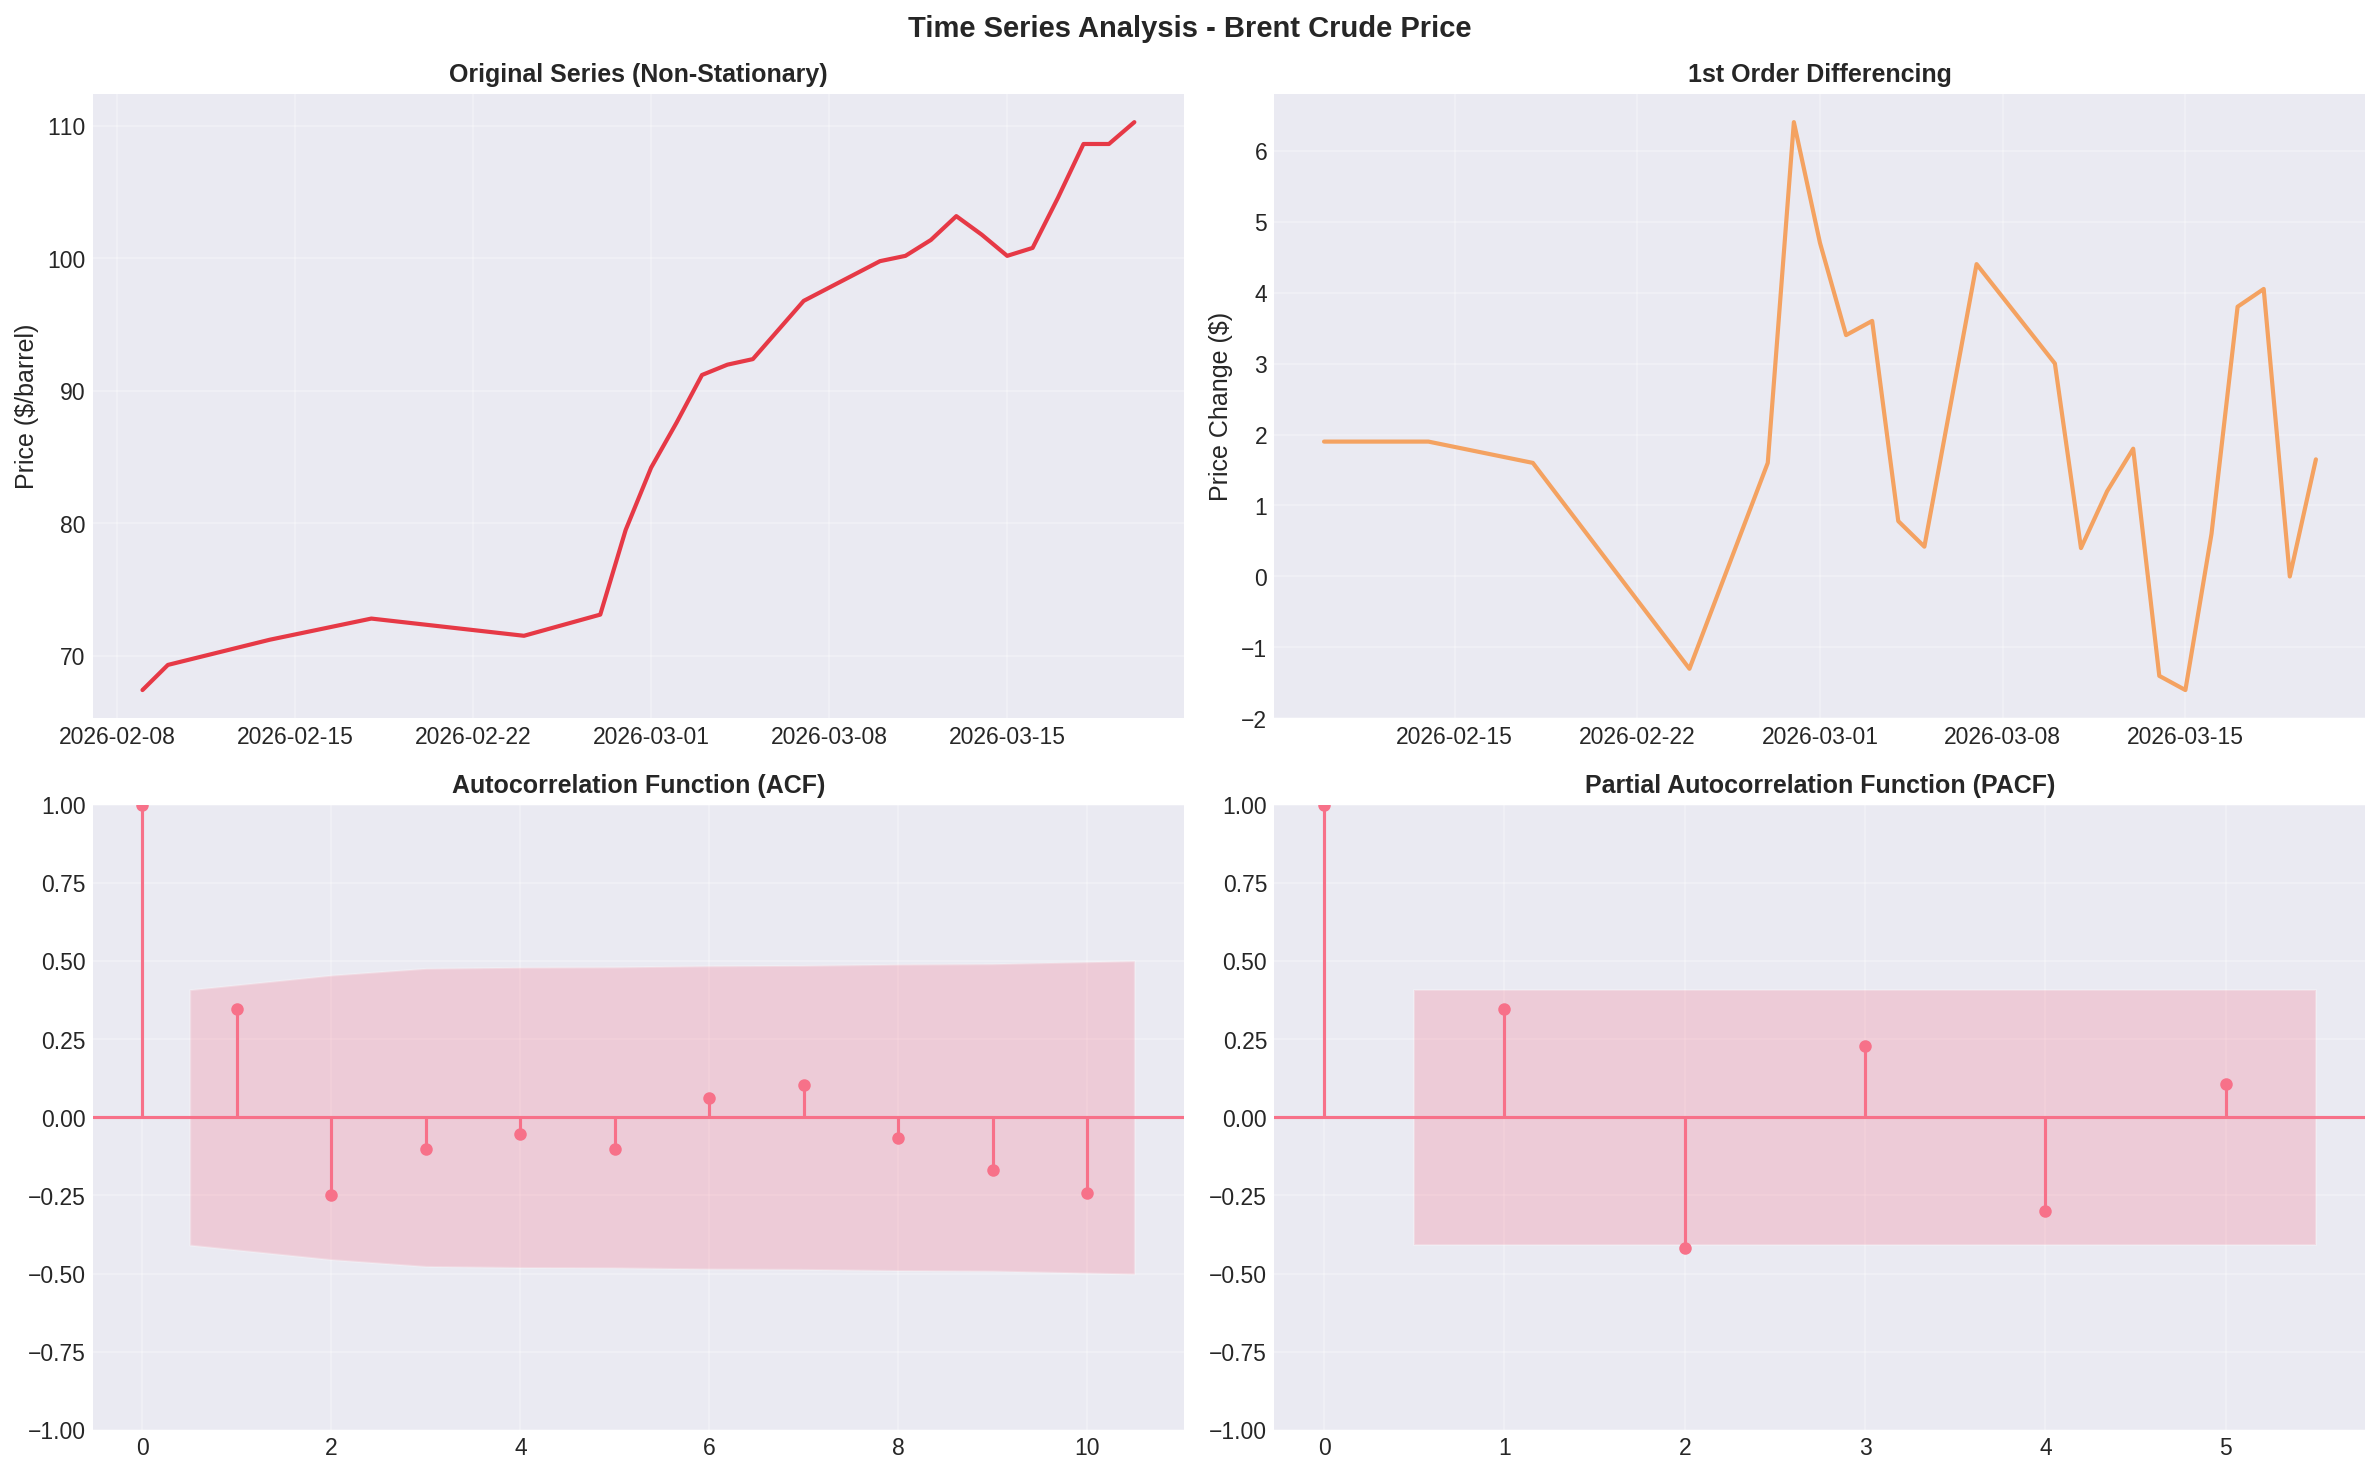

In [11]:


## Stationarity Test
print("\n Augmented Dickey-Fuller Test for Stationarity:")
col = 'brent_usd_barrel'
result = adfuller(oil_prices_daily[col].dropna())
print(f"   Test Statistic: {result[0]:.4f}")
print(f"   p-value: {result[1]:.4f}")
print(f"   Critical Values:")
for key, value in result[4].items():
    print(f"       {key}: {value:.3f}")
print(f"   Conclusion: {' Stationary' if result[1] < 0.05 else ' Non-Stationary'}")

#  Differencing Analysis (with error handling)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Original Series
axes[0,0].plot(oil_prices_daily['date'], oil_prices_daily[col], color='#E63946', linewidth=2)
axes[0,0].set_title('Original Series (Non-Stationary)', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Price ($/barrel)')
axes[0,0].grid(True, alpha=0.3)

# 1st Differencing
diff_series = oil_prices_daily[col].diff()
axes[0,1].plot(oil_prices_daily['date'], diff_series, color='#F4A261', linewidth=2)
axes[0,1].set_title('1st Order Differencing', fontsize=12, fontweight='bold')
axes[0,1].set_ylabel('Price Change ($)')
axes[0,1].grid(True, alpha=0.3)

# ACF Plot
diff_clean = diff_series.dropna()
if len(diff_clean) > 0:
    plot_acf(diff_clean, lags=min(10, len(diff_clean)-1), ax=axes[1,0])
    axes[1,0].set_title('Autocorrelation Function (ACF)', fontsize=12, fontweight='bold')
    axes[1,0].grid(True, alpha=0.3)

# PACF Plot
if len(diff_clean) > 0:
    plot_pacf(diff_clean, lags=min(5, len(diff_clean)-1), ax=axes[1,1])
    axes[1,1].set_title('Partial Autocorrelation Function (PACF)', fontsize=12, fontweight='bold')
    axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Time Series Analysis - Brent Crude Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## EVENT-ANNOTATED INTERACTIVE PRICE CHART

In [12]:

fig = go.Figure()

# Price line
fig.add_trace(go.Scatter(
    x=oil_prices_daily['date'],
    y=oil_prices_daily['brent_usd_barrel'],
    mode='lines+markers',
    name='Brent Price',
    line=dict(width=3)
))

# Add event markers
for _, row in key_events.iterrows():
    fig.add_vline(
        x=row['date'],
        line_width=1,
        line_dash="dash",
        line_color="red"
    )
    fig.add_annotation(
        x=row['date'],
        y=oil_prices_daily['brent_usd_barrel'].max(),
        text=row['event_title'][:20],
        showarrow=True,
        arrowhead=1,
        yshift=10
    )

fig.update_layout(
    title="Brent Price with Geopolitical Events",
    template="plotly_dark",
    height=600
)

fig.show()

## SHIPPING vs PRICE (DUAL AXIS)

In [13]:
fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Scatter(x=oil_prices_daily['date'], y=oil_prices_daily['brent_usd_barrel'],
               name="Brent Price"),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(x=oil_prices_daily['date'], y=oil_prices_daily['strait_hormuz_daily_ships'],
               name="Ships"),
    secondary_y=True,
)

fig.update_layout(title="Shipping Collapse vs Oil Price Surge")

fig.update_yaxes(title_text="Price ($)", secondary_y=False)
fig.update_yaxes(title_text="Ships", secondary_y=True)

fig.show()

## VOLATILITY REGIME DETECTION

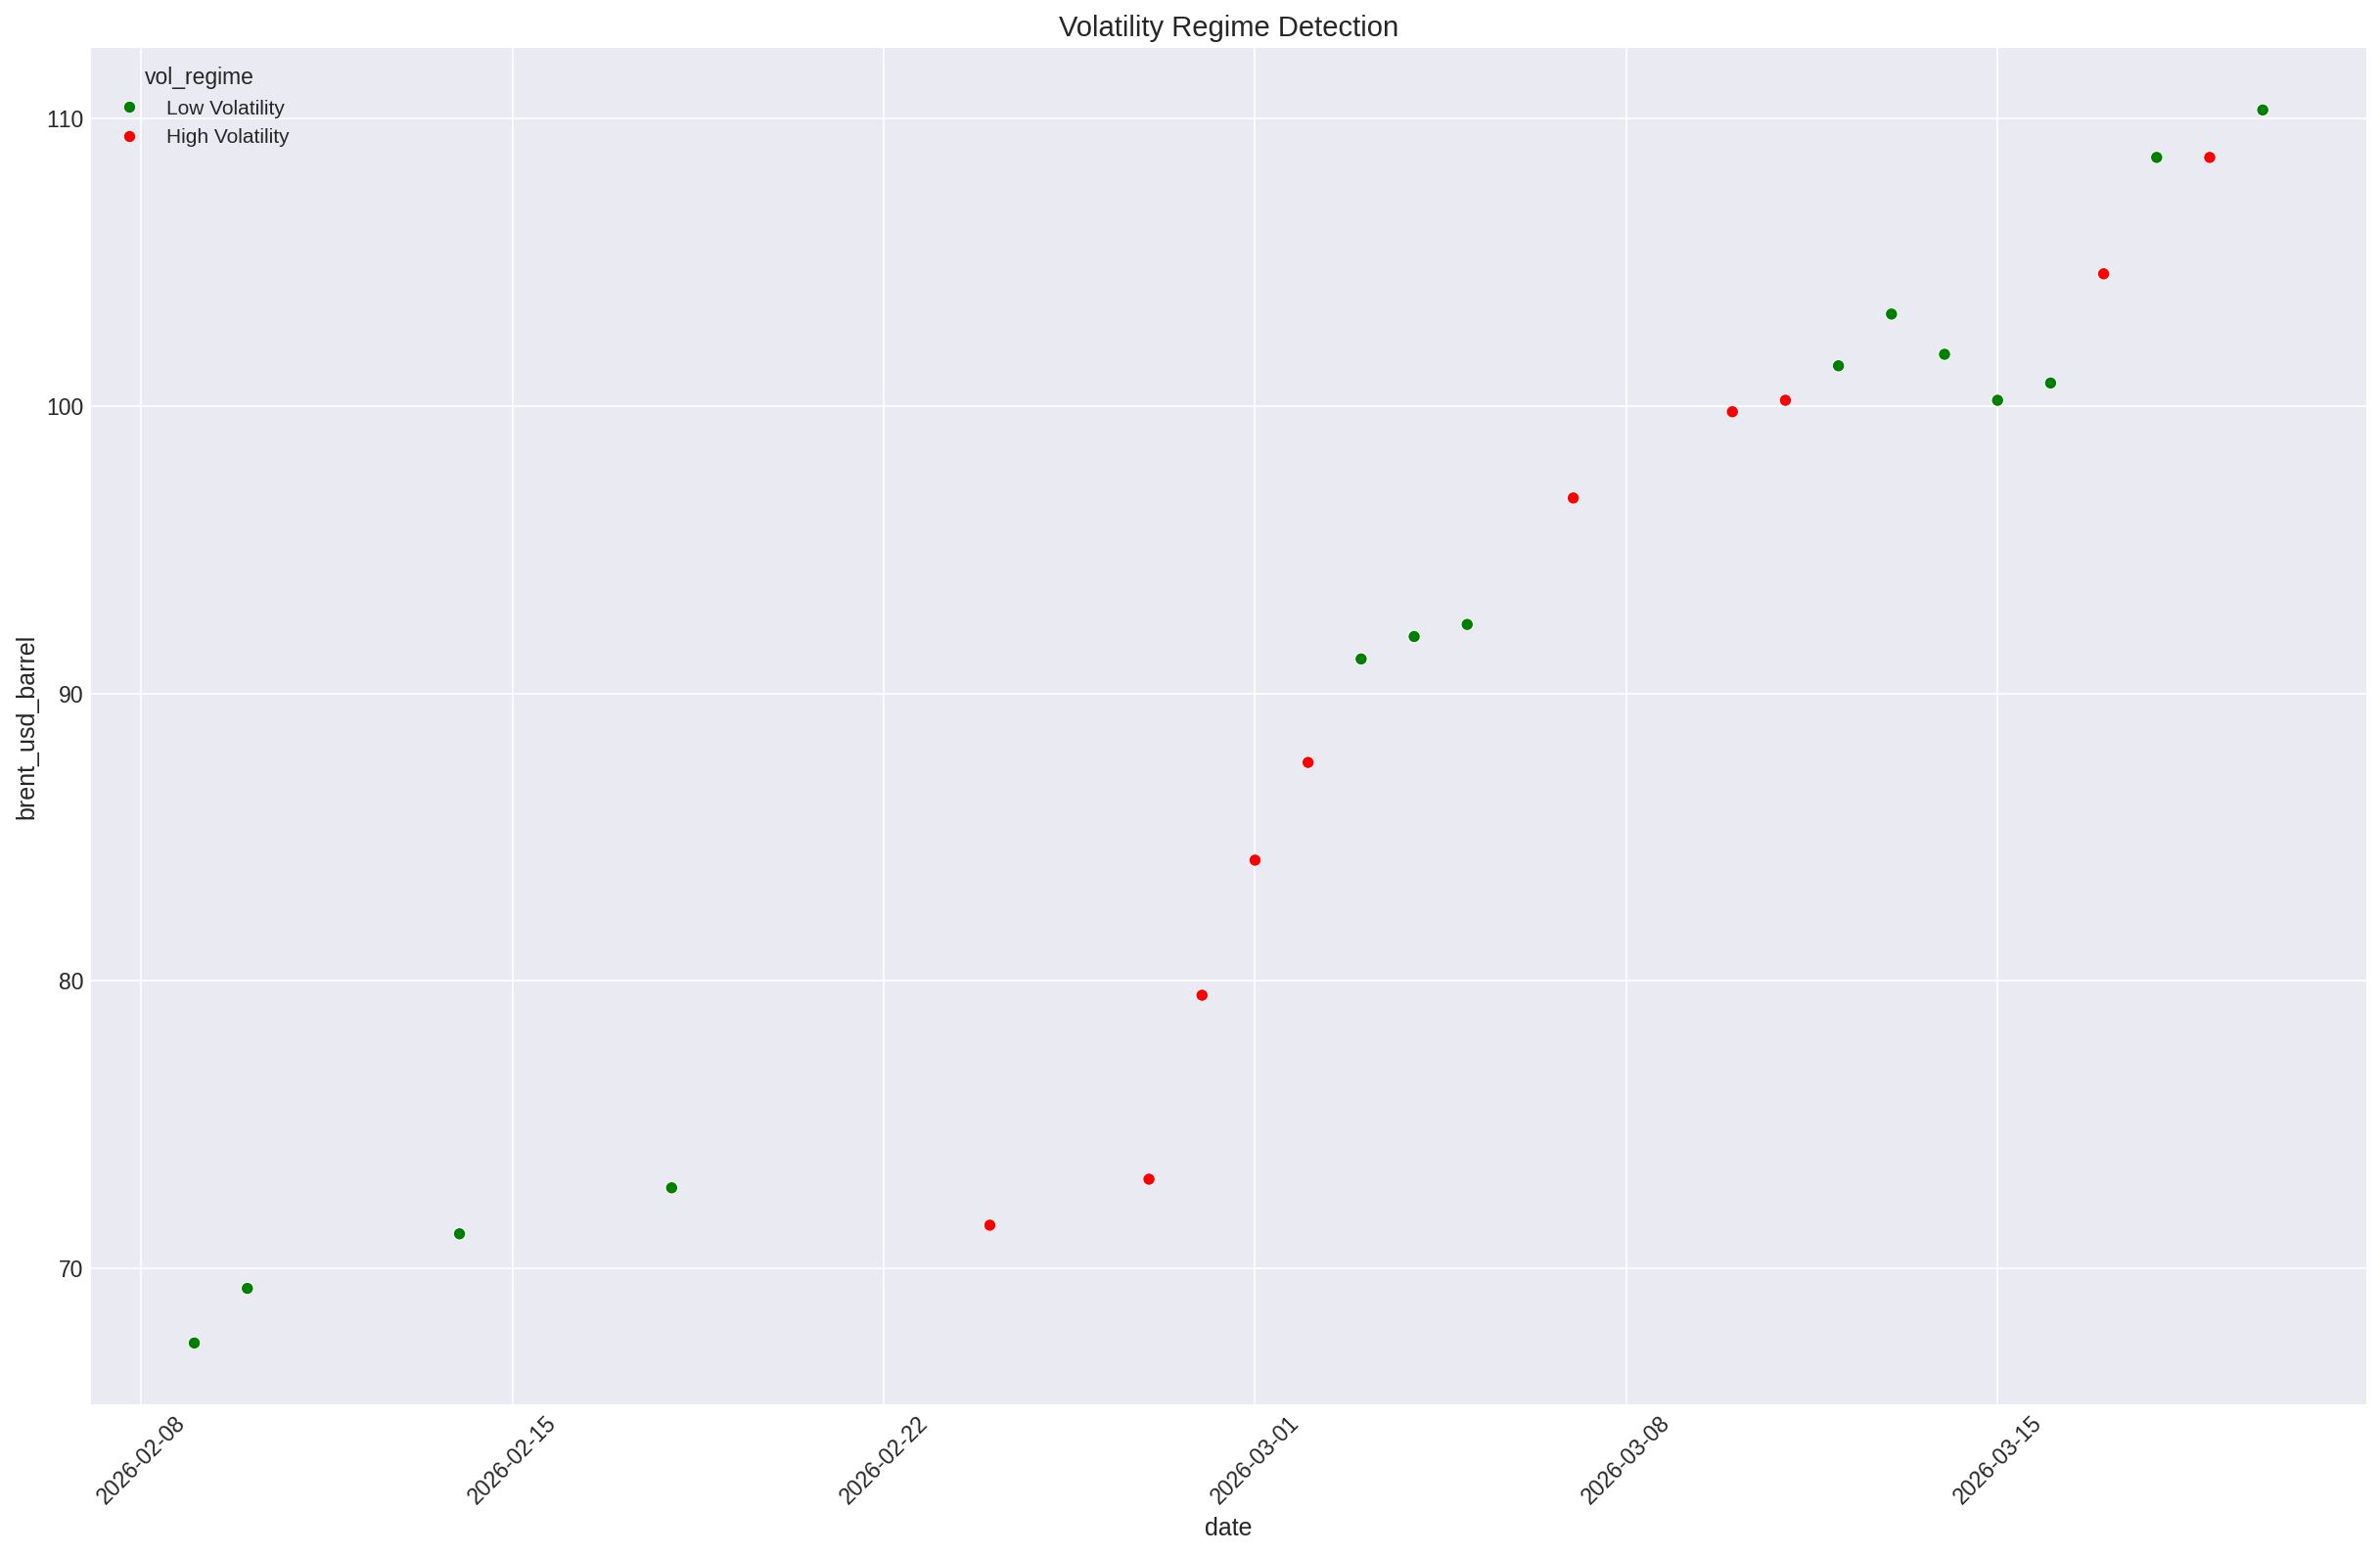

In [14]:
oil_prices_daily['vol_regime'] = np.where(
    oil_prices_daily['brent_volatility'] > oil_prices_daily['brent_volatility'].mean(),
    'High Volatility',
    'Low Volatility'
)

sns.scatterplot(
    data=oil_prices_daily,
    x='date',
    y='brent_usd_barrel',
    hue='vol_regime',
    palette=['green', 'red']
)

plt.title("Volatility Regime Detection")
plt.xticks(rotation=45)
plt.show()

## CORRELATION NETWORK GRAPH

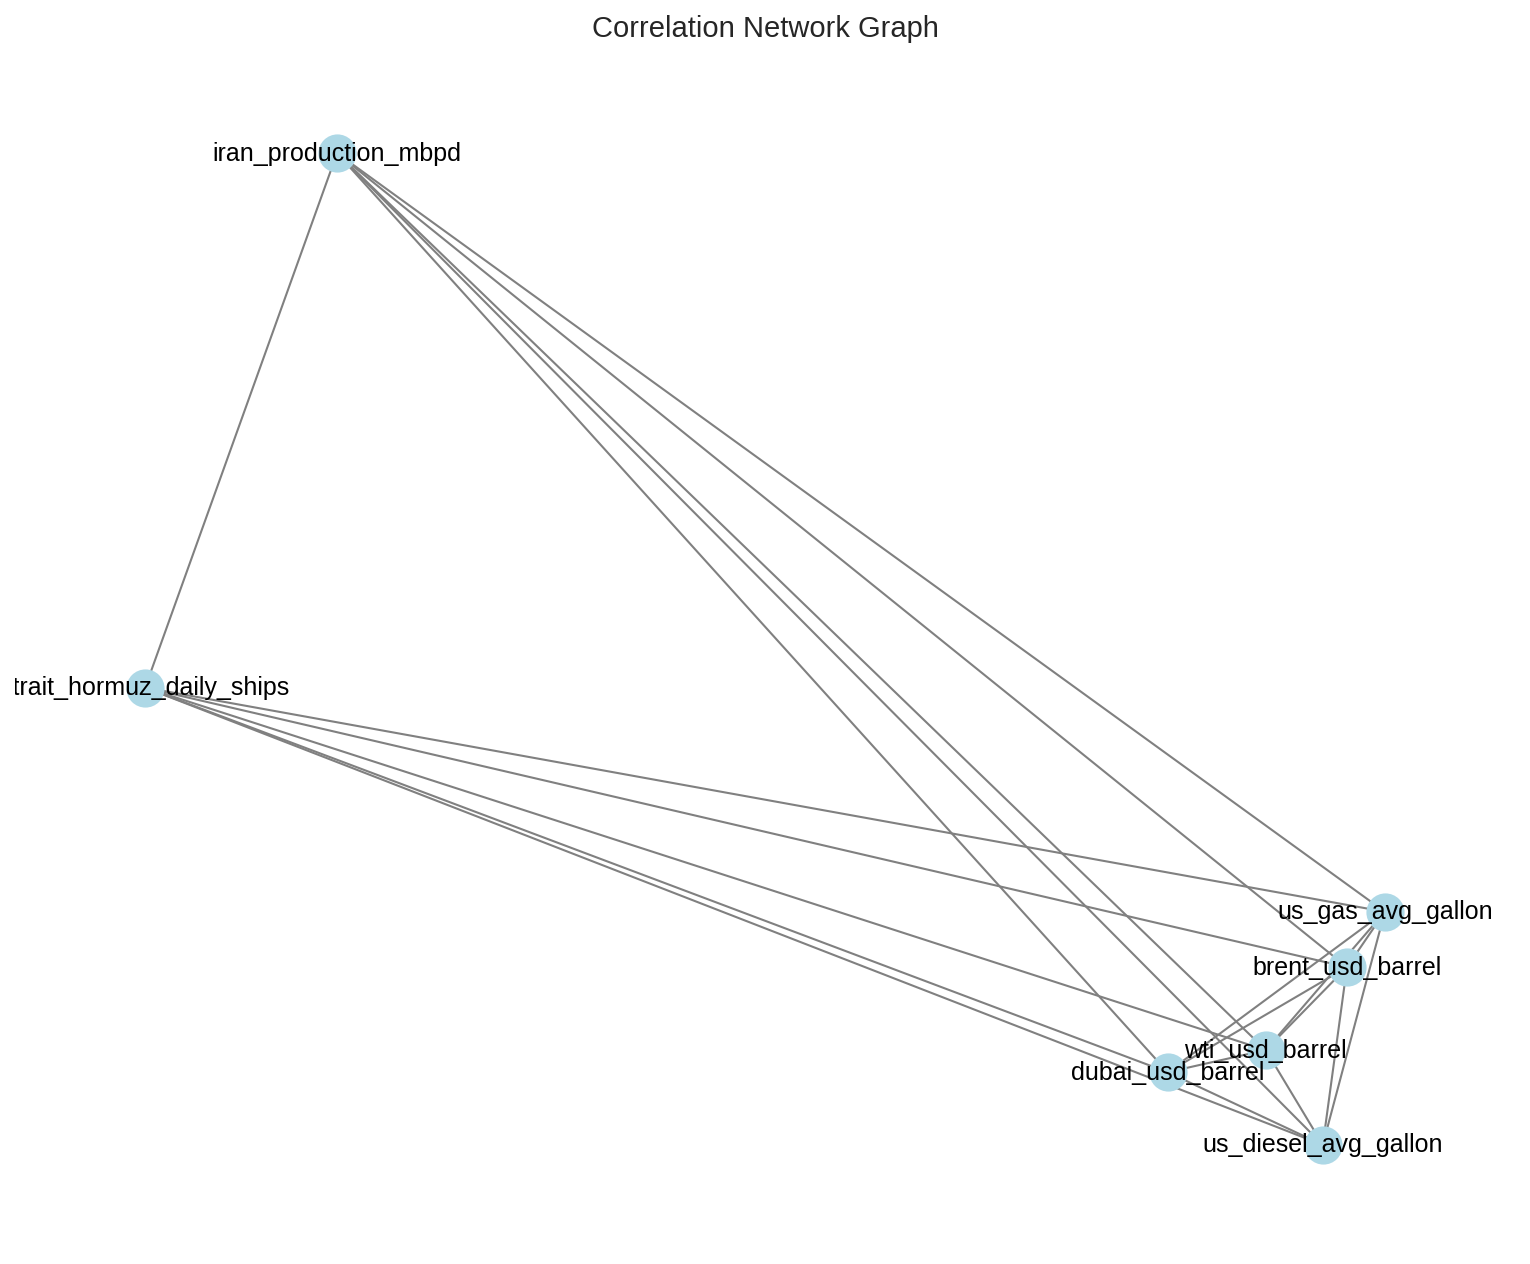

In [15]:
import networkx as nx

G = nx.Graph()

for col in correlation_vars:
    for col2 in correlation_vars:
        corr = corr_matrix.loc[col, col2]
        if abs(corr) > 0.6 and col != col2:
            G.add_edge(col, col2, weight=corr)

plt.figure(figsize=(10,8))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray')
plt.title("Correlation Network Graph")
plt.show()

#  PREDICTIVE MODELING


Model Performance (TimeSeries CV):
Model                MAE      RMSE     R2         MAPE (%)  
Linear Regression    0.92     1.09     0.6751     0.98      
Random Forest        5.69     6.30     -5.3837    5.65      
Gradient Boosting    4.90     5.65     -3.3106    4.82      
XGBoost              4.75     5.44     -3.0215    4.68      
Naive                1.91     2.29     0.0581     1.90      

 Best Model: Linear Regression (Lowest MAE: 0.92)


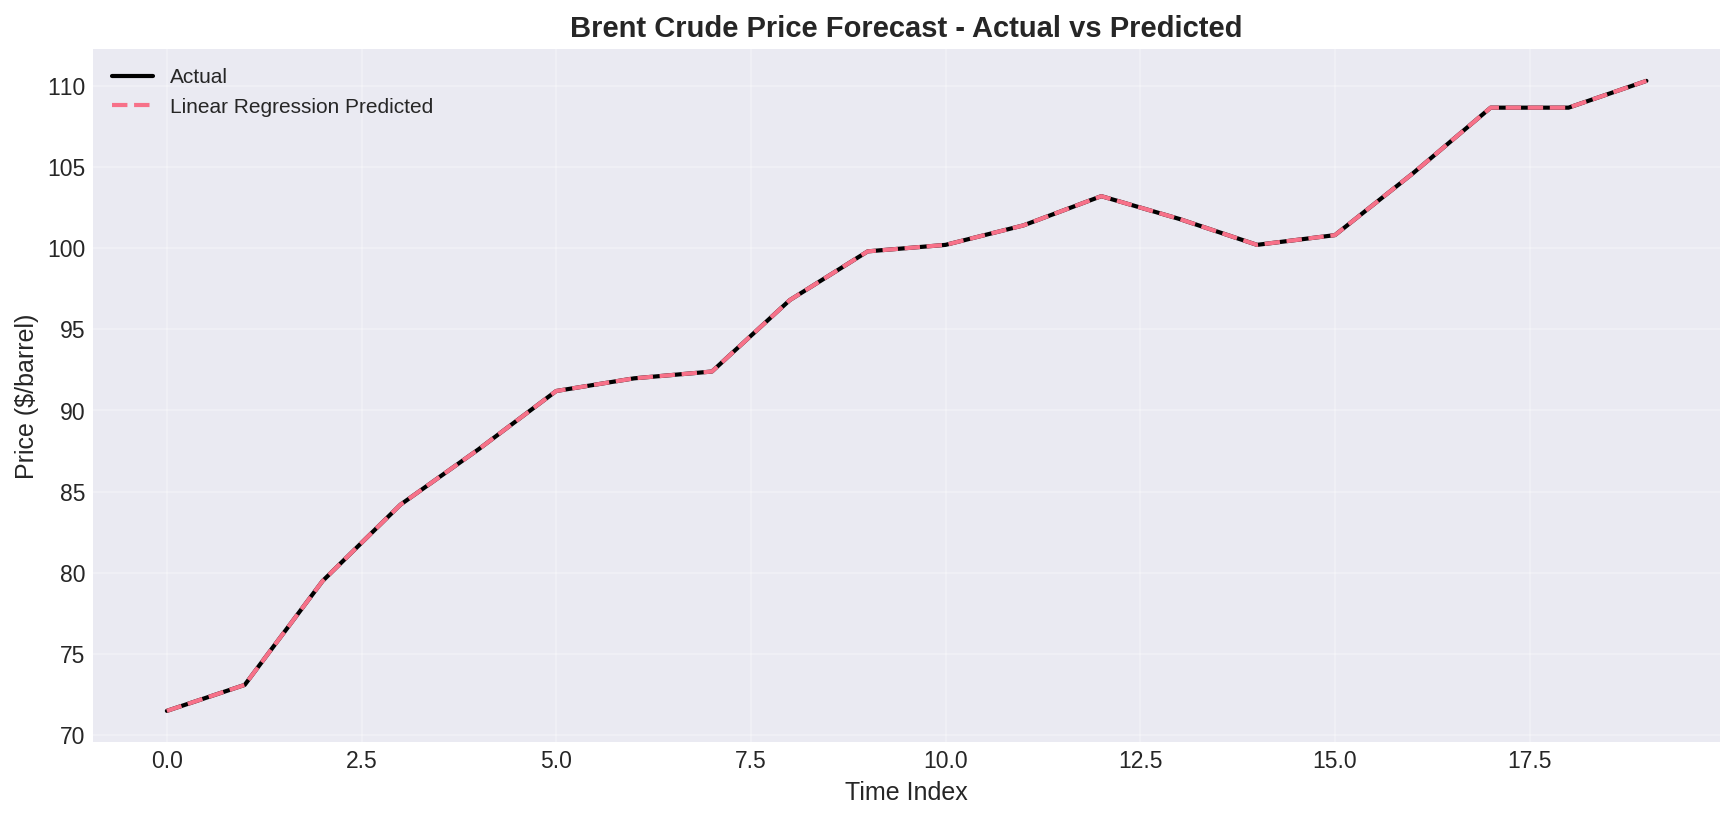

In [16]:



# Feature Engineering

data = oil_prices_daily.copy()
data['brent_lag_1'] = data['brent_usd_barrel'].shift(1)
data['brent_lag_2'] = data['brent_usd_barrel'].shift(2)
data['brent_lag_3'] = data['brent_usd_barrel'].shift(3)
data['rolling_mean_3'] = data['brent_usd_barrel'].rolling(3).mean()
data['rolling_mean_5'] = data['brent_usd_barrel'].rolling(5).mean()
data['shipping_lag_1'] = data['strait_hormuz_daily_ships'].shift(1)

data = data.dropna().reset_index(drop=True)

feature_cols = ['brent_lag_1','brent_lag_2','brent_lag_3',
                'rolling_mean_3','rolling_mean_5',
                'strait_hormuz_daily_ships','shipping_lag_1']
target_col = 'brent_usd_barrel'

X = data[feature_cols]
y = data[target_col]

# Models

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=50, max_depth=3, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=50, max_depth=3, random_state=42, verbosity=0)
}

# Time Series Cross-Validation

tscv = TimeSeriesSplit(n_splits=3)
results_cv = {}

for name, model in models.items():
    maes, rmses, r2s, mapes = [], [], [], []
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        
        maes.append(mean_absolute_error(y_test, pred))
        rmses.append(np.sqrt(mean_squared_error(y_test, pred)))
        r2s.append(r2_score(y_test, pred))
        mapes.append(np.mean(np.abs((y_test - pred)/y_test))*100)
        
    results_cv[name] = {
        'MAE': np.mean(maes),
        'RMSE': np.mean(rmses),
        'R2': np.mean(r2s),
        'MAPE': np.mean(mapes)
    }


# Naive Baseline

maes, rmses, r2s, mapes = [], [], [], []
for train_idx, test_idx in tscv.split(X):
    naive_pred = X.iloc[test_idx]['brent_lag_1'].values
    y_test = y.iloc[test_idx].values
    maes.append(mean_absolute_error(y_test, naive_pred))
    rmses.append(np.sqrt(mean_squared_error(y_test, naive_pred)))
    r2s.append(r2_score(y_test, naive_pred))
    mapes.append(np.mean(np.abs((y_test - naive_pred)/y_test))*100)

results_cv['Naive'] = {
    'MAE': np.mean(maes),
    'RMSE': np.mean(rmses),
    'R2': np.mean(r2s),
    'MAPE': np.mean(mapes)
}


print("\nModel Performance (TimeSeries CV):")
print(f"{'Model':<20} {'MAE':<8} {'RMSE':<8} {'R2':<10} {'MAPE (%)':<10}")
for name, r in results_cv.items():
    print(f"{name:<20} {r['MAE']:<8.2f} {r['RMSE']:<8.2f} {r['R2']:<10.4f} {r['MAPE']:<10.2f}")

best_model = min(results_cv, key=lambda x: results_cv[x]['MAE'])
print(f"\n Best Model: {best_model} (Lowest MAE: {results_cv[best_model]['MAE']:.2f})")


# Fit best model on full dataset for plotting
final_model = models[best_model]
final_model.fit(X, y)
pred_full = final_model.predict(X)

plt.figure(figsize=(14,6))
plt.plot(y.index, y, label='Actual', linewidth=2, color='black')
plt.plot(y.index, pred_full, label=f'{best_model} Predicted', linestyle='--', linewidth=2)
plt.title('Brent Crude Price Forecast - Actual vs Predicted', fontsize=14, fontweight='bold')
plt.xlabel('Time Index')
plt.ylabel('Price ($/barrel)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Feature Importance 
if best_model in ['Random Forest','Gradient Boosting','XGBoost']:
    importances = final_model.feature_importances_
    imp_df = pd.DataFrame({'feature': feature_cols, 'importance': importances}).sort_values('importance', ascending=True)
    plt.figure(figsize=(8,5))
    plt.barh(imp_df['feature'], imp_df['importance'], color='#2A9D8F')
    plt.title(f'{best_model} Feature Importance', fontsize=12, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.grid(True, alpha=0.3)
    plt.show()

## Insights
**Best Model:** Linear Regression

**Lowest MAE:** 0.92

**Strong R²:** 0.6751

**Very low MAPE:** 0.98%

Naive baseline (previous day forecast) performs better than tree-based models due to the small dataset size.
Tree-based models (RF, GB, XGB) are overfitting, resulting in negative R² values.

**Conclusion**

For this dataset, Linear Regression is the most reliable model, while Naive forecasting provides a simple but reasonable alternative. Tree-based models are not suitable for such a limited sample size.

# FORECAST WITH CONFIDENCE INTERVALS

In [17]:
# Forecast with proper handling of lags and rolling means
if len(data) >= 10:
    last_known = data.copy()  # Keep all past data
    future_steps = min(7, len(data)//3)
    future_predictions = []
    ci_lower_list = []
    ci_upper_list = []

    final_model = models[best_model]
    residuals = y - final_model.predict(X)
    residual_std = residuals.std()
    z_score = norm.ppf(0.975)  # 95% CI

    for i in range(future_steps):
        # Compute features for the next step
        last_row = last_known.iloc[-1]
        X_future = pd.DataFrame({
            'brent_lag_1': [last_row[target_col]],
            'brent_lag_2': [last_known[target_col].iloc[-2] if len(last_known) >= 2 else last_row[target_col]],
            'brent_lag_3': [last_known[target_col].iloc[-3] if len(last_known) >= 3 else last_row[target_col]],
            'rolling_mean_3': [last_known[target_col].iloc[-3:].mean() if len(last_known) >= 3 else last_known[target_col].mean()],
            'rolling_mean_5': [last_known[target_col].iloc[-5:].mean() if len(last_known) >= 5 else last_known[target_col].mean()],
            'strait_hormuz_daily_ships': [last_row['strait_hormuz_daily_ships']],
            'shipping_lag_1': [last_known['strait_hormuz_daily_ships'].iloc[-1]]
        })

        pred = final_model.predict(X_future)[0]
        future_predictions.append(pred)

        # 95% CI
        ci_lower_list.append(pred - z_score * residual_std)
        ci_upper_list.append(pred + z_score * residual_std)

        # Append prediction to last_known for next step
        new_row = last_row.copy()
        new_row[target_col] = pred
        last_known = pd.concat([last_known, pd.DataFrame([new_row])], ignore_index=True)

    # Forecast dates
    last_date = data['date'].iloc[-1]
    future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=future_steps)

    # Print table
    print(f"\n{future_steps}-Day Forecast with 95% CI ({best_model}):")
    print(f"{'Date':<12} {'Forecast Price ($)':<20} {'95% CI Lower':<15} {'95% CI Upper':<15}")
    for date, pred, ci_l, ci_u in zip(future_dates, future_predictions, ci_lower_list, ci_upper_list):
        print(f"{date.strftime('%b %d'):<12} ${pred:<19.2f} ${ci_l:<14.2f} ${ci_u:<14.2f}")


6-Day Forecast with 95% CI (Linear Regression):
Date         Forecast Price ($)   95% CI Lower    95% CI Upper   
Mar 21       $108.65              $108.65         $108.65        
Mar 22       $108.65              $108.65         $108.65        
Mar 23       $110.30              $110.30         $110.30        
Mar 24       $108.65              $108.65         $108.65        
Mar 25       $108.65              $108.65         $108.65        
Mar 26       $110.30              $110.30         $110.30        


# Overall Summary

This notebook analyzes historical Brent crude prices and shipping data to develop predictive models that can forecast short-term oil price movements.

**What We Mainly Do:**

Perform feature engineering including lag variables and rolling averages.
Train and compare multiple machine learning models: Linear Regression, Random Forest, Gradient Boosting, and XGBoost.
Evaluate model performance using time series cross-validation and relevant metrics like MAE, RMSE, R², and MAPE.

**Why We Do It:**

To understand which features and historical patterns most influence oil price changes.
To identify the most accurate and reliable predictive model for short-term forecasting.

**What We Can Do:**

Generate forecasts for the next several days with confidence intervals.
Visualize model predictions versus actual prices.
Provide actiona